In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn import tree
import time
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [4]:
def LoadData(X_filename,Y_filename):
    '''
    Input: Get 2 filenames, 1 for x_data and 1 for y_data
    Output: Two numpy array of X and Y data
    '''
    X = pd.read_csv(X_filename,delimiter=';')
    Y = pd.read_csv(Y_filename,delimiter=';')
    X = X.to_numpy()
    Y = Y.to_numpy()
    return X,Y
    

In [7]:
def GetFeatureNames(X_filename):
    X = pd.read_csv(X_filename,delimiter=';')
    feature_names = X.columns
    return feature_names

In [9]:
def SplitTrainTestRandom(X,Y):
    '''
    ***COMPLETED - NO CHANGES ARE REQUIRED***
    
    Input: feature matrix X, labels vector Y
    Output: X_train, Y_train - train data
            X_test, Y_test - test data
    '''
    
    # permute the ordering of the examples
    # random inds every running 
    ind = np.random.permutation(len(Y))
    
    # choose the size of the training data
    Ntrain = int(0.8 * len(Y))
    # split the data into train and test datasets
    
    X_train = X[ind[:Ntrain]]
    Y_train = Y[ind[:Ntrain]]
    X_test  = X[ind[Ntrain:]]
    Y_test  = Y[ind[Ntrain:]]
    
    return X_train, Y_train, X_test, Y_test

## cross-validation

degree = 1,k=0
degree = 1,k=1
degree = 1,k=2
degree = 1,k=3
degree = 1,k=4
degree = 1,k=5
degree = 1,k=6
degree = 1,k=7
degree = 1,k=8
degree = 1,k=9
degree = 2,k=0
degree = 2,k=1
degree = 2,k=2
degree = 2,k=3
degree = 2,k=4
degree = 2,k=5
degree = 2,k=6
degree = 2,k=7
degree = 2,k=8
degree = 2,k=9
degree = 3,k=0
degree = 3,k=1
degree = 3,k=2
degree = 3,k=3
degree = 3,k=4
degree = 3,k=5
degree = 3,k=6
degree = 3,k=7
degree = 3,k=8
degree = 3,k=9


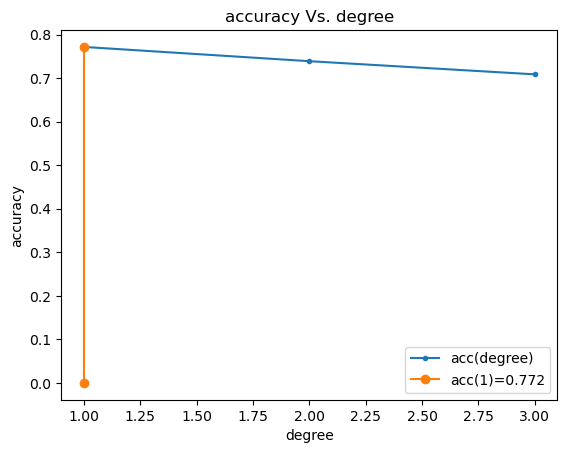

In [9]:
running_num = 10
X,Y = LoadData("X_data.csv","Y_data.csv")
degree_arr = np.array([1,2,3])
svc = SVC(kernel='poly',C=10)
acc_total = np.array([])

for i in degree_arr:
    # initial conditions
    acc = np.array([])
    svc.set_params(degree = i)
    for k in range(running_num):
        print(f'degree = {i},k={k}')
        X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
        svc.fit(X_train,Y_train)
        acc = np.append(acc, svc.score(X_test,Y_test))
    acc_total = np.append(acc_total,acc.mean())

# Accruacy plot
plt.plot(degree_arr,acc_total,'.-')
plt.plot([degree_arr[acc_total.argmax()],degree_arr[acc_total.argmax()]],[0,acc_total.max()],'-o')
plt.xlabel('degree')
plt.ylabel('accuracy')
plt.title('accuracy Vs. degree')    
plt.legend(['acc(degree)',f'acc({degree_arr[acc_total.argmax()]})={np.round(acc_total.max(),3)}'])
plt.show()

C = 0.1
C = 1.0
C = 10.0
C = 100.0


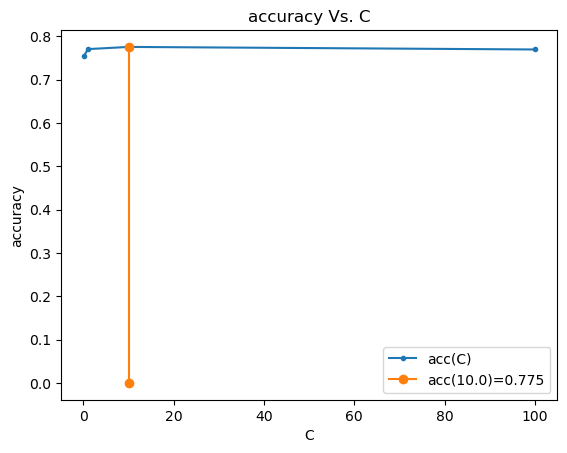

In [19]:
running_num = 10
X,Y = LoadData("X_data.csv","Y_data.csv")
X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
C_arr = np.array([0.1,1,10,100])
svc = SVC(kernel='poly',degree=1)
acc_total = np.array([])


for i in C_arr:
    # initial conditions
    acc = np.array([])
    svc.set_params(C = i)
    print(f'C = {svc.C}')
    for k in range(running_num):
        X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
        svc.fit(X_train,Y_train)
        acc = np.append(acc, svc.score(X_test,Y_test))
    acc_total = np.append(acc_total,acc.mean())

# Accruacy plot
plt.plot(C_arr,acc_total,'.-')
plt.plot([C_arr[acc_total.argmax()],C_arr[acc_total.argmax()]],[0,acc_total.max()],'-o')
plt.xlabel('C')
plt.ylabel('accuracy')
plt.title('accuracy Vs. C')    
plt.legend(['acc(C)',f'acc({C_arr[acc_total.argmax()]})={np.round(acc_total.max(),3)}'])
plt.show()

## Optimum parameters 

In [23]:
X,Y = LoadData("X_data.csv","Y_data.csv")
start_time = time.time()
running_num = 40
acc = np.array([])
for i in range(running_num):
    X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
    svc = SVC(kernel='poly',degree=1,C=1).fit(X_train,Y_train)
    acc = np.append(acc,svc.score(X_test,Y_test))
stop_time = time.time()
execution_time = stop_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")
acc.mean()

Execution time: 22.1129 seconds


0.7743593563766388

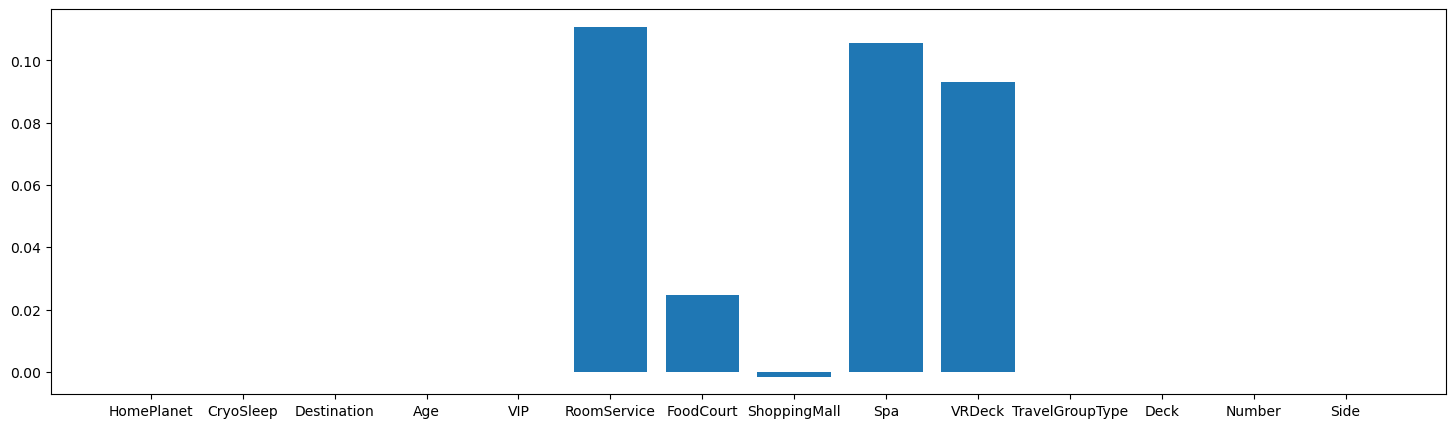

In [29]:
from sklearn.inspection import permutation_importance
feature_names = GetFeatureNames("X_data.csv")
result = permutation_importance(svc, X_test, Y_test, n_repeats=30, random_state=42)
importances = result.importances_mean

plt.figure(figsize=(18,5))
plt.bar(range(len(importances)), importances) 
plt.xticks(ticks=range(len(feature_names)),labels=feature_names)
plt.show()